# COMP8325 Applications of Artificial Intelligence for Cyber Security
## Group 13
# Task 1: Model Training


## Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder

RANDOM_STATE = 42

## Load Dataset

In [5]:
# Load the dataset
data = np.load('bodmas.npz')
print('Keys in the dataset:', list(data.keys()))

# Extract features and labels
X_all = data['X'] # Feature matrix
y_binary = data['y'] # Binary labels: 0 = benign, 1 = malignant

# Encode the labels if they are not already in numeric format
print(f'Feature matrix shape: {X_all.shape}')
print(f'Binary labels shape: {y_binary.shape}')
print(f'Benign samples: {(y_binary == 0).sum()}')
print(f'Malignant samples: {(y_binary == 1).sum()}')

Keys in the dataset: ['X', 'y']
Feature matrix shape: (134435, 2381)
Binary labels shape: (134435,)
Benign samples: 77142
Malignant samples: 57293


## Load Metadata and Categories

In [6]:
# Load metadata
metadata = pd.read_csv('bodmas_metadata.csv')
metadata = metadata.rename(columns={'sha': 'sha256'})

# Load malware category labels
categories = pd.read_csv('bodmas_malware_category.csv')

# Display dataset information
print(f'Metadata shape: {metadata.shape}')
print(f'Categories shape: {categories.shape}')
print('\nCategory distribution: ')
print(categories["category"].value_counts())


Metadata shape: (134435, 3)
Categories shape: (57293, 2)

Category distribution: 
category
trojan                29972
worm                  16697
backdoor               7331
downloader             1031
ransomware              821
dropper                 715
informationstealer      448
virus                   192
pua                      29
cryptominer              20
p2p-worm                 16
exploit                  12
trojan-gamethief          6
rootkit                   3
Name: count, dtype: int64


## Data Preprocessing

Number of labelled samples: 134435
Dropped samples due to missing labels: 0
Final feature matrix shape: (134435, 2381)
Final labels shape: (134435,)
Nan count after cleaning: 0
Inf count after cleaning: 0

Classes (15): ['backdoor' 'benign' 'cryptominer' 'downloader' 'dropper' 'exploit'
 'informationstealer' 'p2p-worm' 'pua' 'ransomware' 'rootkit' 'trojan'
 'trojan-gamethief' 'virus' 'worm']


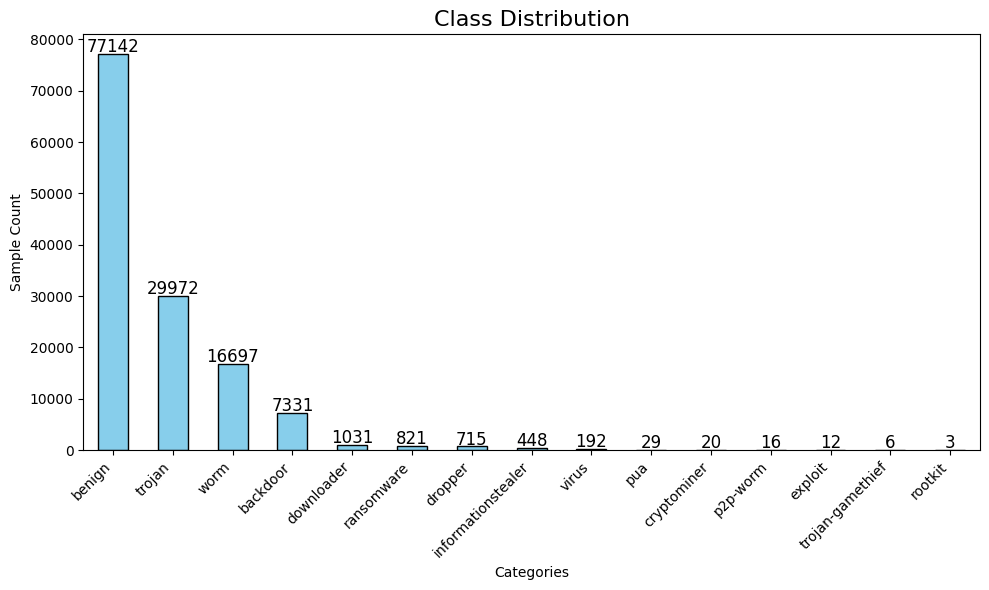

In [11]:
# Merge categories labels with metadata
metadata['binary_label'] = y_binary
meta_merged = metadata.merge(categories, on='sha256', how='left')
meta_merged.loc[meta_merged['binary_label'] == 0, 'category'] = 'benign'

# Drop rows with missing category labels
labelled_mask = meta_merged['category'].notna()
print(f'Number of labelled samples: {labelled_mask.sum()}')
print(f'Dropped samples due to missing labels: {(~labelled_mask).sum()}')

X = X_all[labelled_mask.values]
y_labels = meta_merged.loc[labelled_mask, 'category'].values
print(f'Final feature matrix shape: {X.shape}')
print(f'Final labels shape: {y_labels.shape}')

# Replace Nan and Inf values with LIEF features
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print(f'Nan count after cleaning: {np.isnan(X).sum()}')
print(f'Inf count after cleaning: {np.isinf(X).sum()}')

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_
print(f'\nClasses ({len(class_names)}): {class_names}')

# class distribution plot
cat_count = pd.Series(y_labels).value_counts()
plt.figure(figsize=(10, 6))
ax = cat_count.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution', fontsize=16)
plt.xlabel('Categories')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.savefig('class_distribution.png', dpi=300)
plt.show()


## Train-Test Split

Training samples: 107548
Test samples: 26887
Features: 2381

Class distribution in Train and Test sets:
                    Train   Test  Train %  Test %
backdoor             5865   1466     5.45    5.45
benign              61714  15428    57.38   57.38
cryptominer            16      4     0.01    0.01
downloader            825    206     0.77    0.77
dropper               572    143     0.53    0.53
exploit                10      2     0.01    0.01
informationstealer    358     90     0.33    0.33
p2p-worm               13      3     0.01    0.01
pua                    23      6     0.02    0.02
ransomware            657    164     0.61    0.61
rootkit                 2      1     0.00    0.00
trojan              23977   5995    22.29   22.30
trojan-gamethief        5      1     0.00    0.00
virus                 153     39     0.14    0.15
worm                13358   3339    12.42   12.42


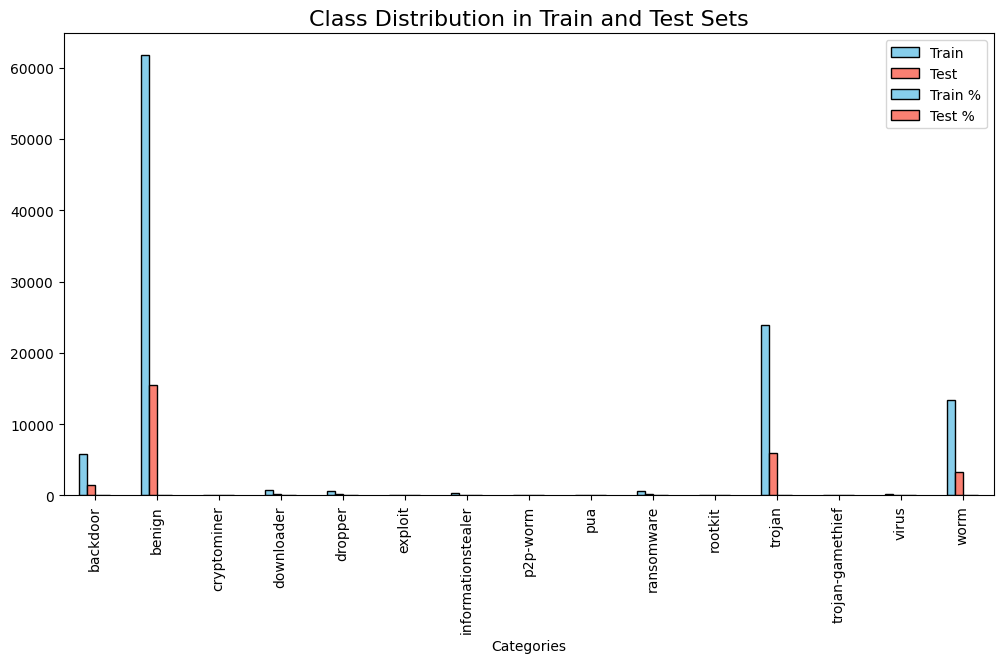

In [16]:
# 80/20 split - preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print(f'Features: {X_train.shape[1]}')

# Verify class distribution in train and test sets
train_dist = pd.Series(label_encoder.inverse_transform(y_train)).value_counts()
test_dist = pd.Series(label_encoder.inverse_transform(y_test)).value_counts()
split_check = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
split_check['Train %'] = (split_check['Train'] / split_check['Train'].sum() * 100).round(2)
split_check['Test %'] = (split_check['Test'] / split_check['Test'].sum() * 100).round(2)
split_check.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution in Train and Test Sets', fontsize=16)
plt.xlabel('Categories')
print('\nClass distribution in Train and Test sets:')
print(split_check)


## Model 1 - Gaussian Naive Bayes

## Model 2 - Random Forest

## Evaluation Function and Models

## Model Comparison